In [ ]:
%load_ext autoreload
%autoreload 2
import os
import torch
import matplotlib.pyplot as plt
import numpy as np

from compactreasoningmodels.solvers import (
    MAC, GeneticAlgorithmDET, GeneticAlgorithmDEP,
    GDGlobalAdamSolver, GDGlobalSGDSolver, 
    GDGaussSeidelAdamSolver, GDGaussSeidelSGDSolver, 
    GDJacobiAdamSolver, GDJacobiSGDSolver,
    ModelSolver
)
from compactreasoningmodels.datasets import NonogramDataset
from compactreasoningmodels.utils.display import display_grid

if 'original_dir' not in globals():
    original_dir = os.getcwd()

os.chdir(os.path.join(original_dir, ".."))
os.environ["DATA_DIR"] = os.path.join(os.getcwd(), "data")
os.environ["MODEL_DIR"] = os.path.join(os.getcwd(), "models")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


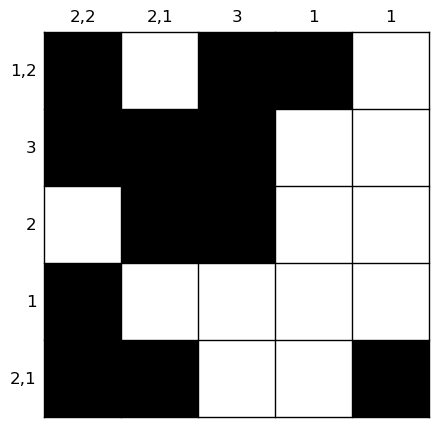

In [10]:
dataset = NonogramDataset("raw/nonogram_5x5.jsonl", max_size=5)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True) 
sample_clues, sample_grids, _, _ = next(iter(dataloader))
sample_clues = sample_clues.squeeze(0).reshape(2, 5, 3)
sample_grids = sample_grids.squeeze(0).reshape(5, 5)
fig, ax = plt.subplots(figsize=(5, 5))
display_grid(ax, sample_grids, clues=sample_clues, title='')

In [ ]:
def display_solution_trace(solver, clues, display_steps=6, sampling_ratio=0.5, step_ratio=1):
    fig, axes = plt.subplots(1, display_steps, figsize=(5 * display_steps, 5))
    print(type(clues))
    print(clues.shape)
    
    traces = solver.step(clues, num_steps=display_steps, sampling_ratio=sampling_ratio, step_ratio=step_ratio)
    for i, step in enumerate(range(1, display_steps + 1)):
        display_grid(axes[i], traces[step], clues=clues, title=f'Step {step}')

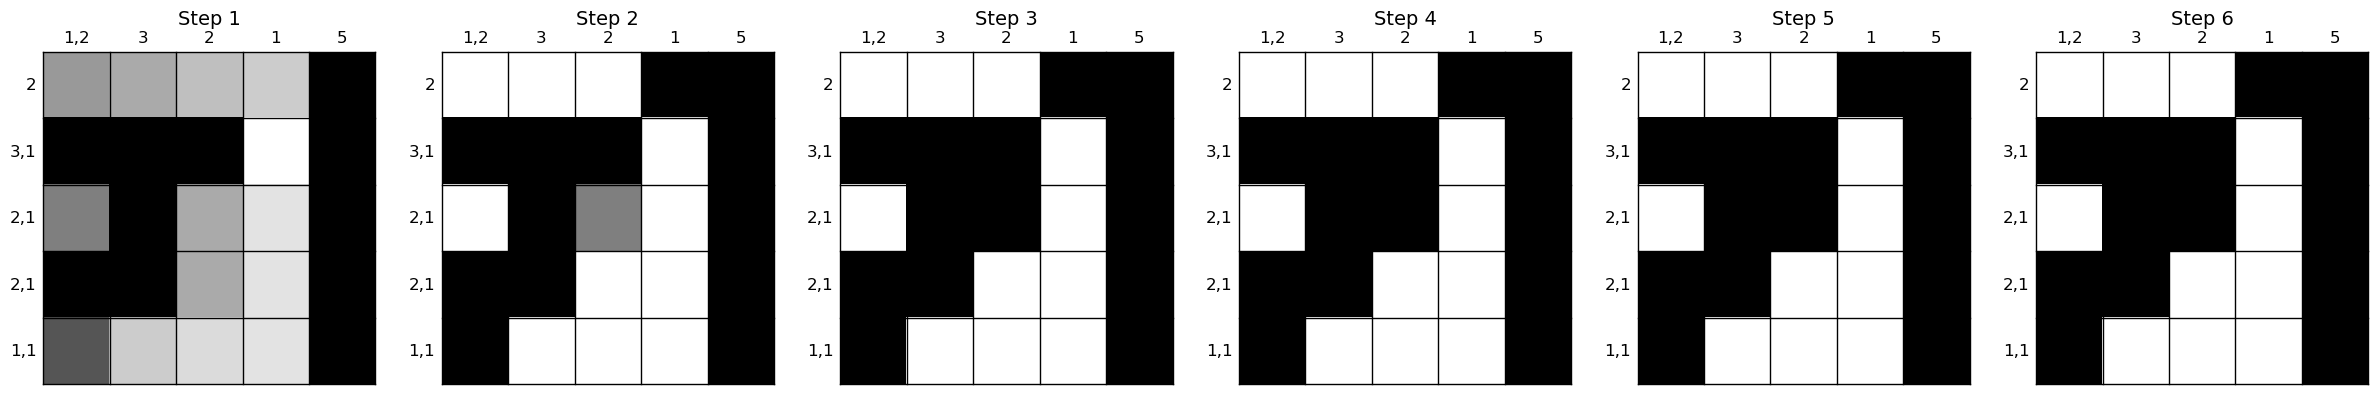

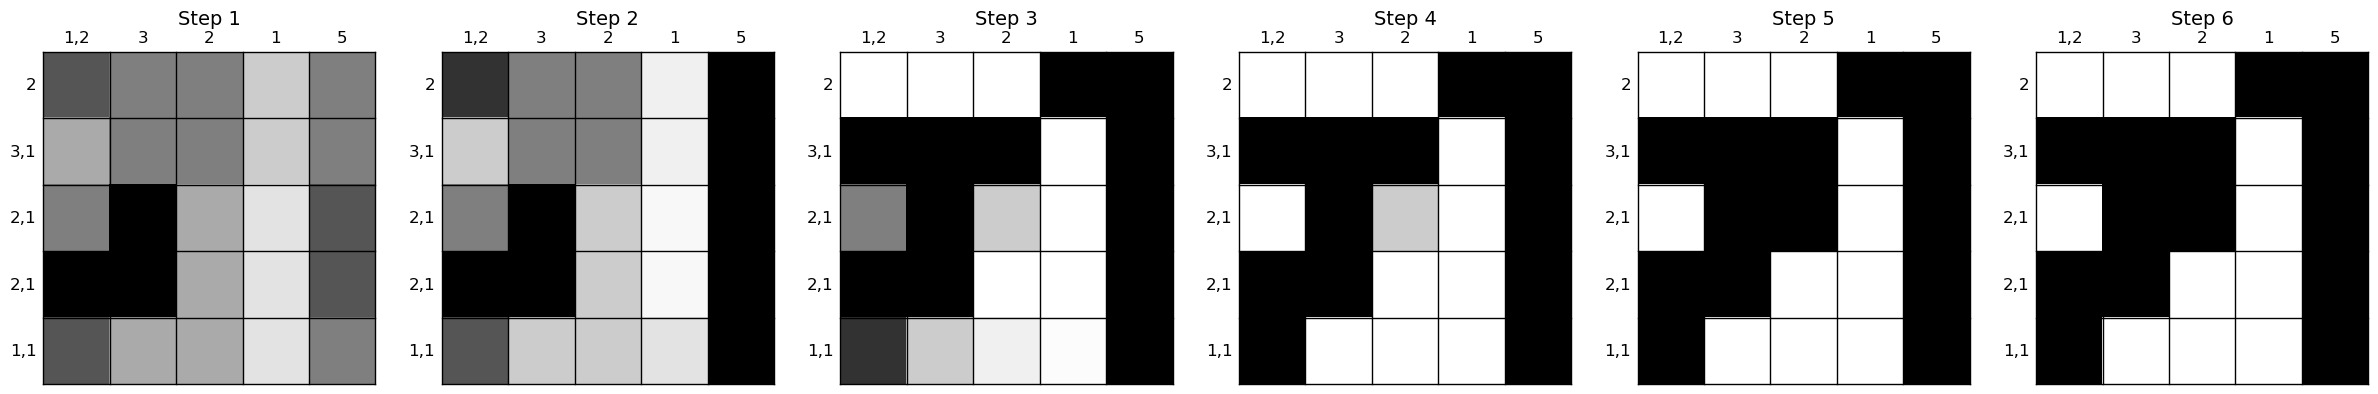

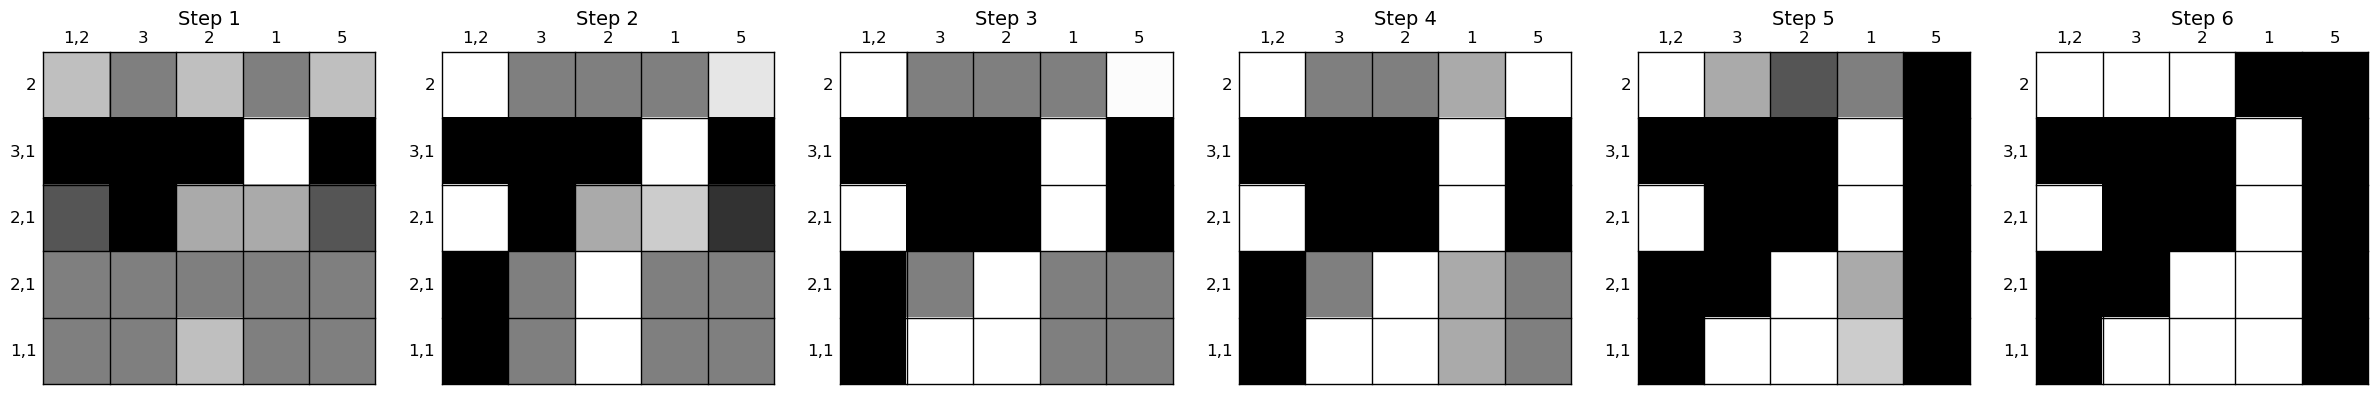

In [14]:
display_solution_trace(MAC(), sample_clues, display_steps=6, sampling_ratio=1.0)
display_solution_trace(MAC(), sample_clues, display_steps=6, sampling_ratio=0.5)
display_solution_trace(MAC(), sample_clues, display_steps=6, sampling_ratio=0.5)

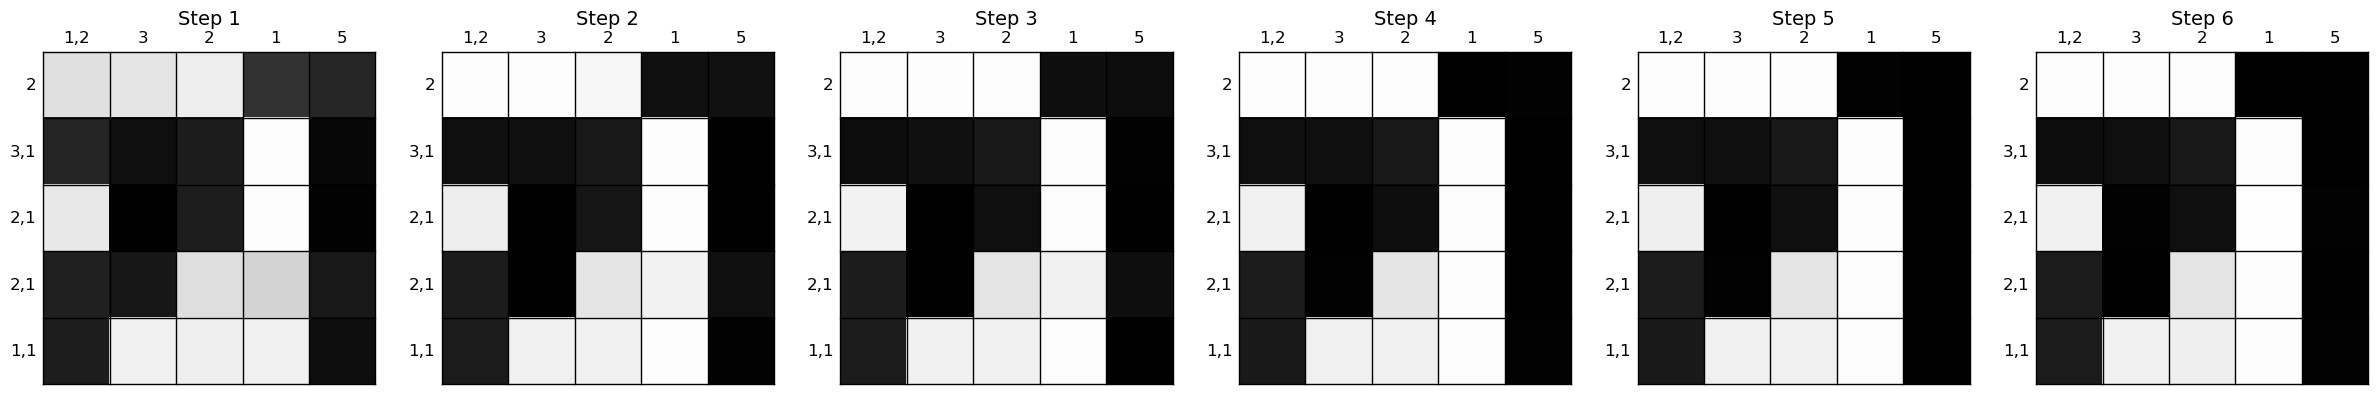

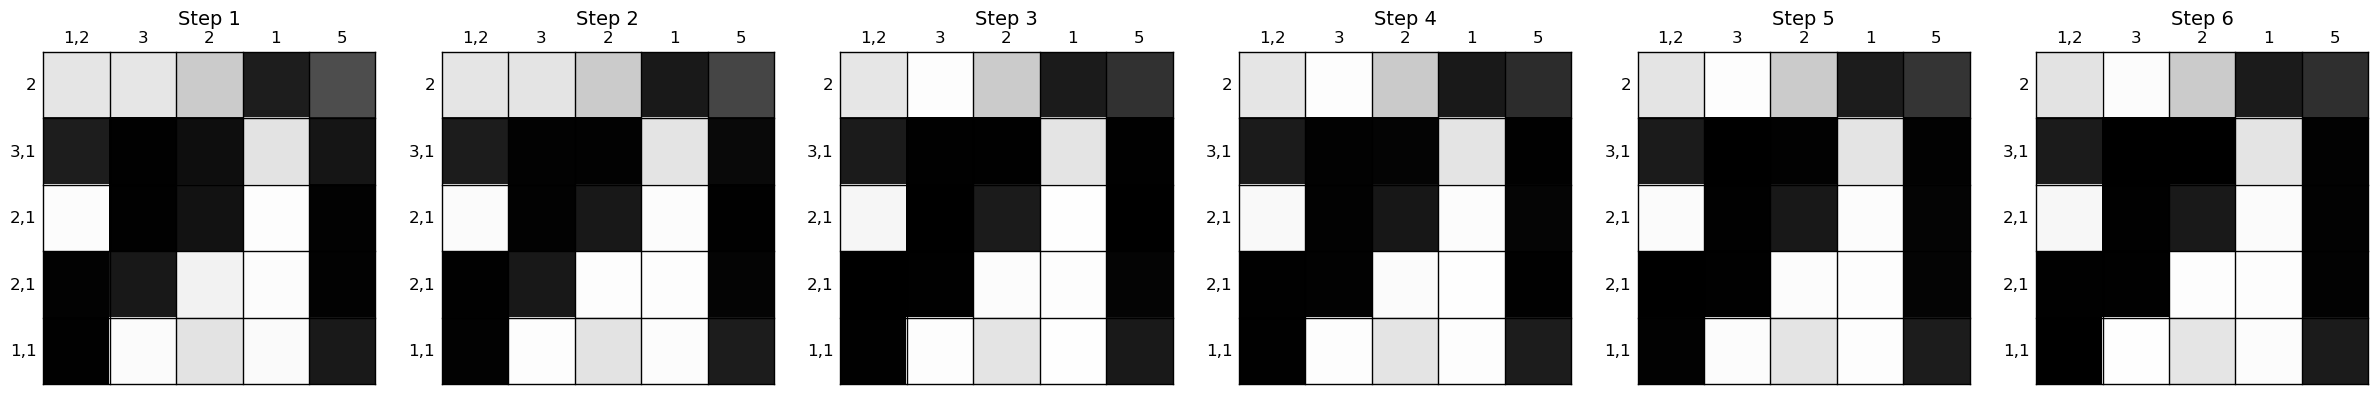

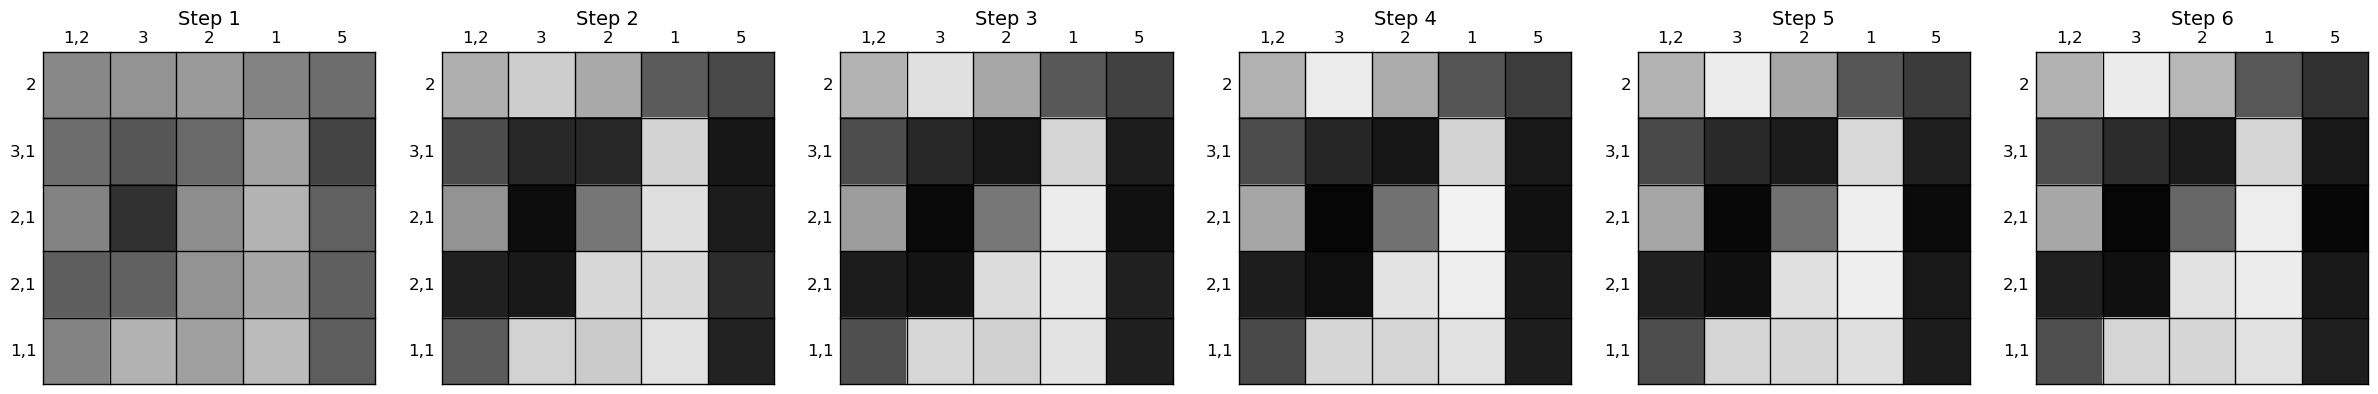

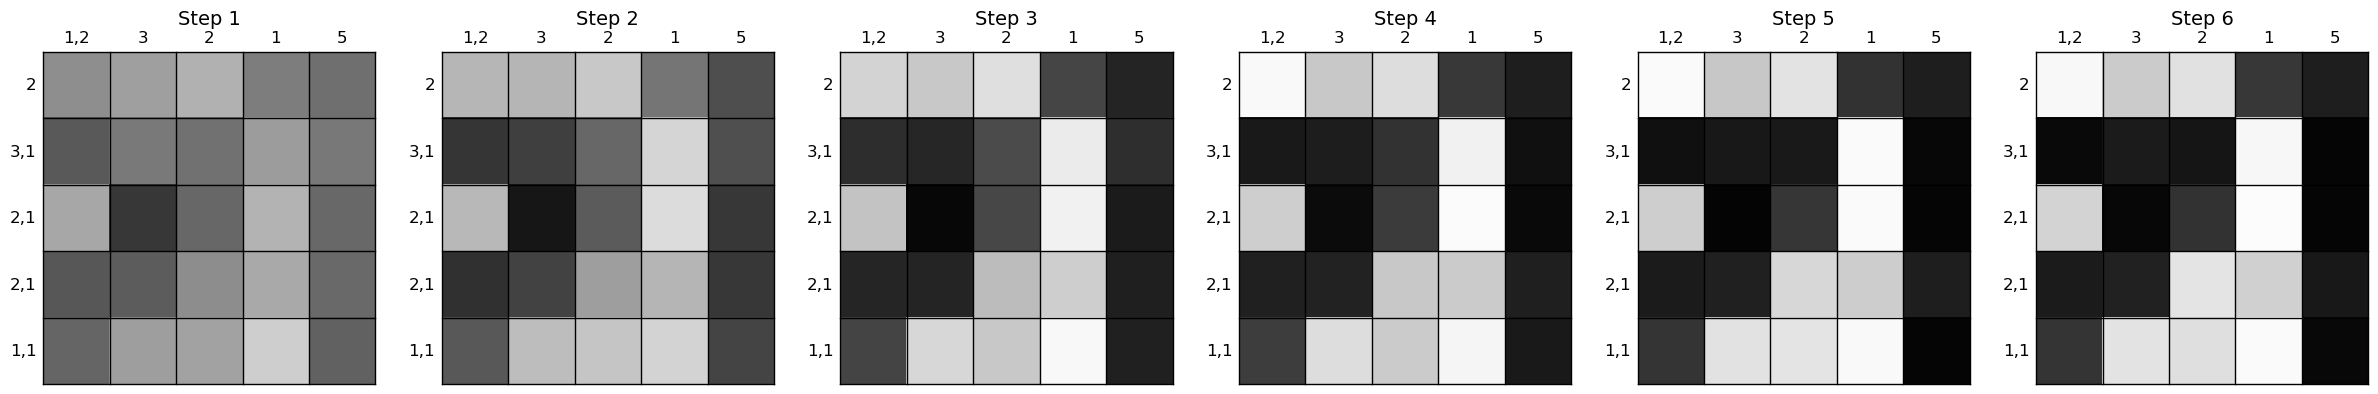

In [15]:
display_solution_trace(GeneticAlgorithmDET(population_size=100), sample_clues, display_steps=6, sampling_ratio=1.0, step_ratio=20)
display_solution_trace(GeneticAlgorithmDET(population_size=100), sample_clues, display_steps=6, sampling_ratio=0.5, step_ratio=20)
display_solution_trace(GeneticAlgorithmDEP(population_size=100), sample_clues, display_steps=6, sampling_ratio=1.0, step_ratio=20)
display_solution_trace(GeneticAlgorithmDEP(population_size=100), sample_clues, display_steps=6, sampling_ratio=0.5, step_ratio=20)


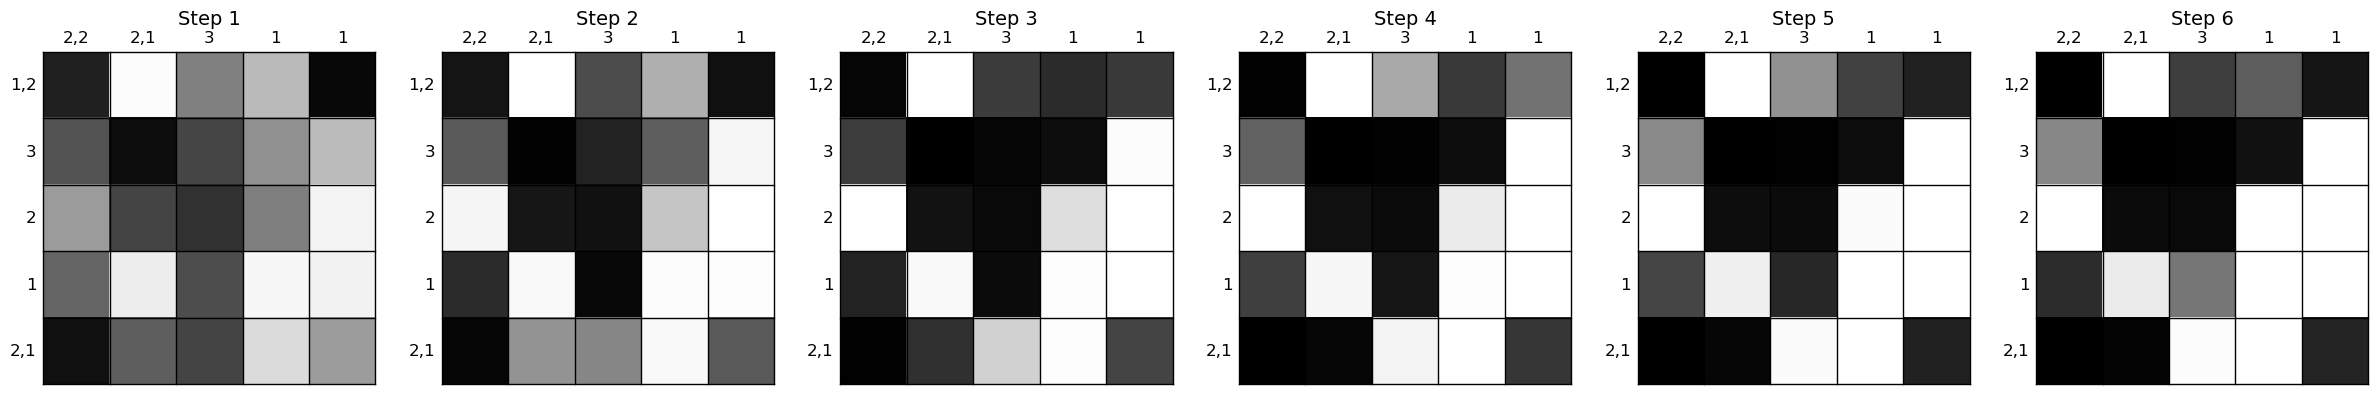

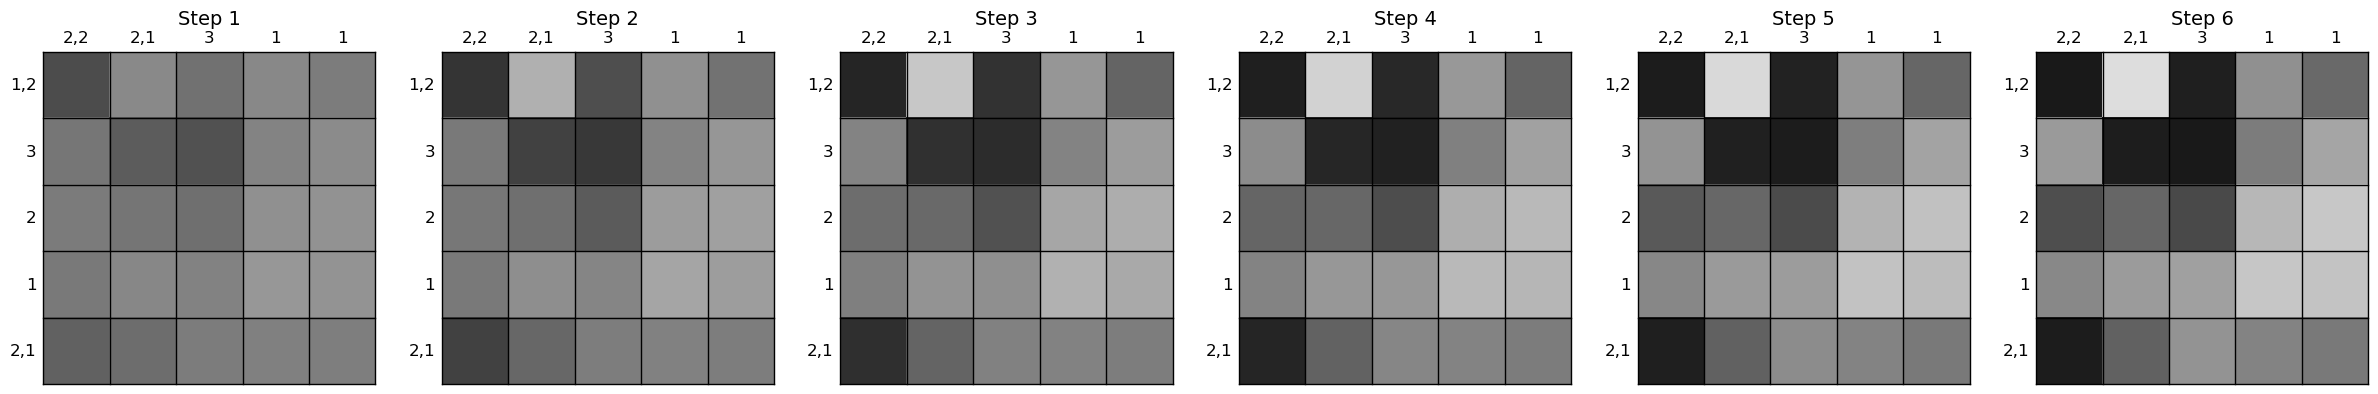

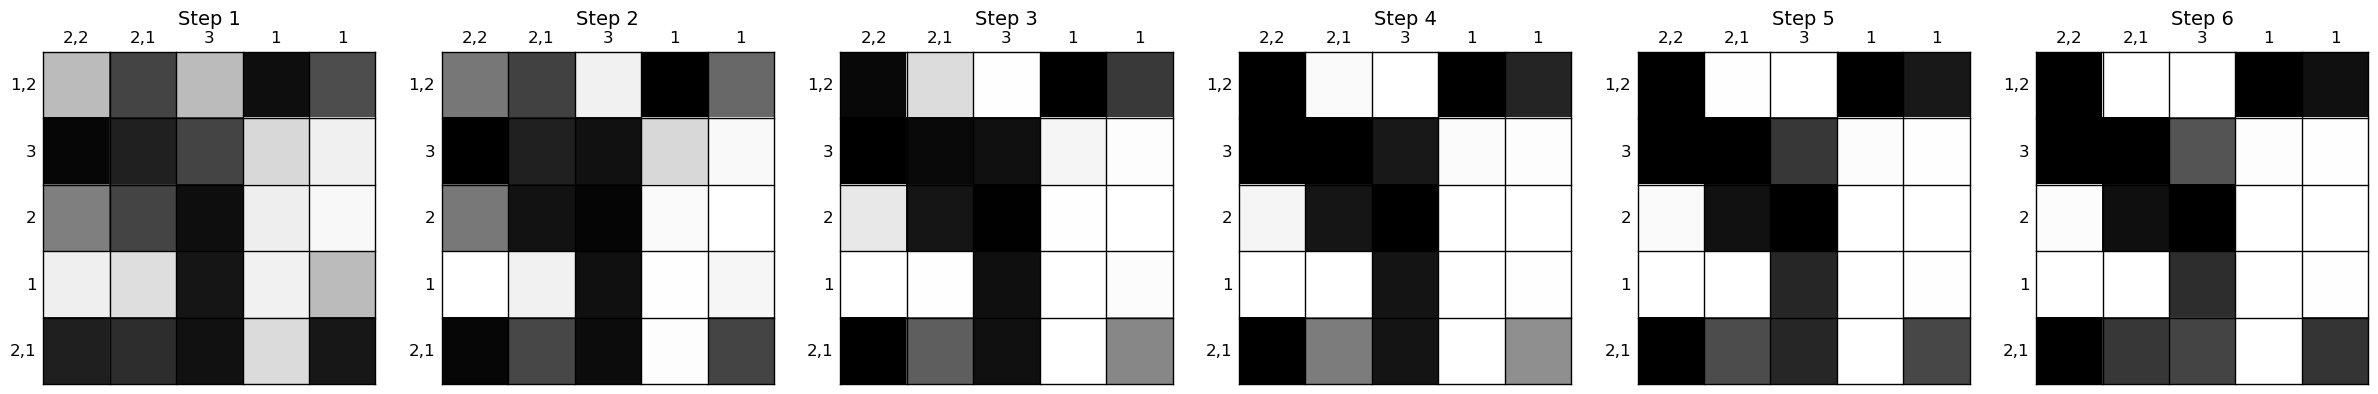

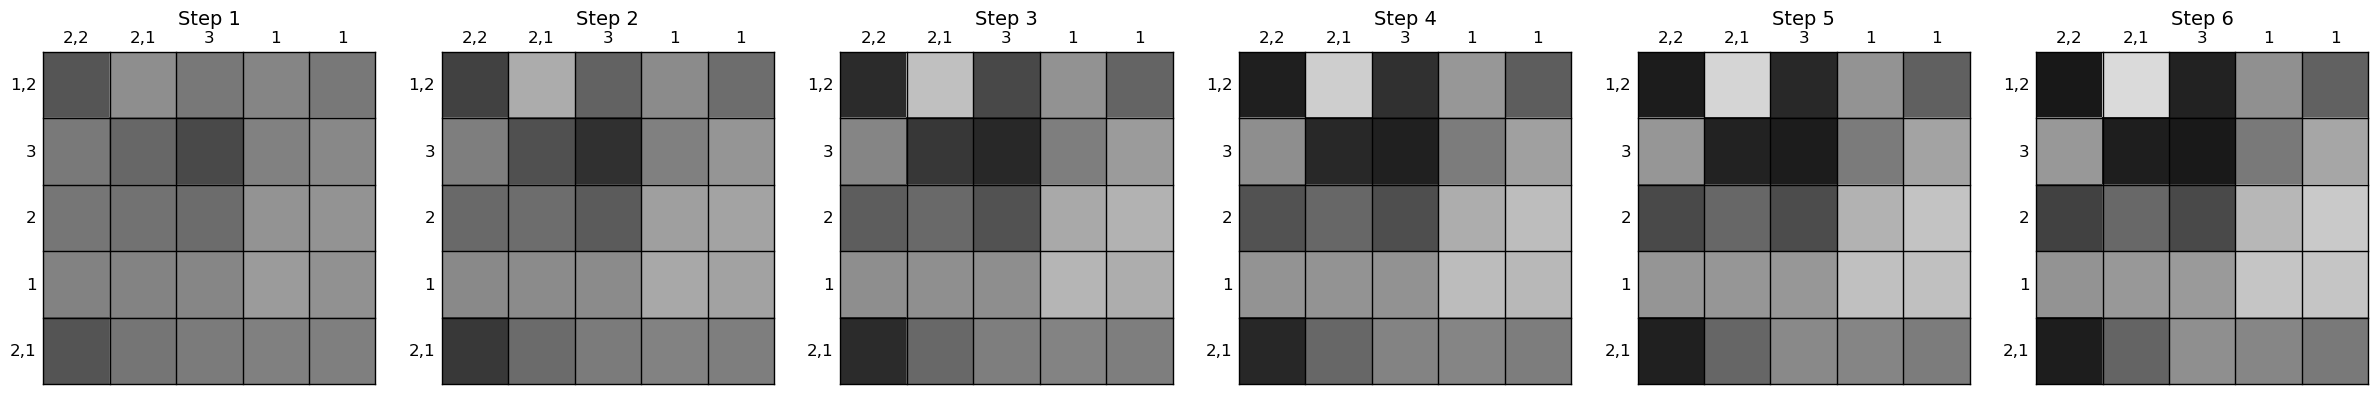

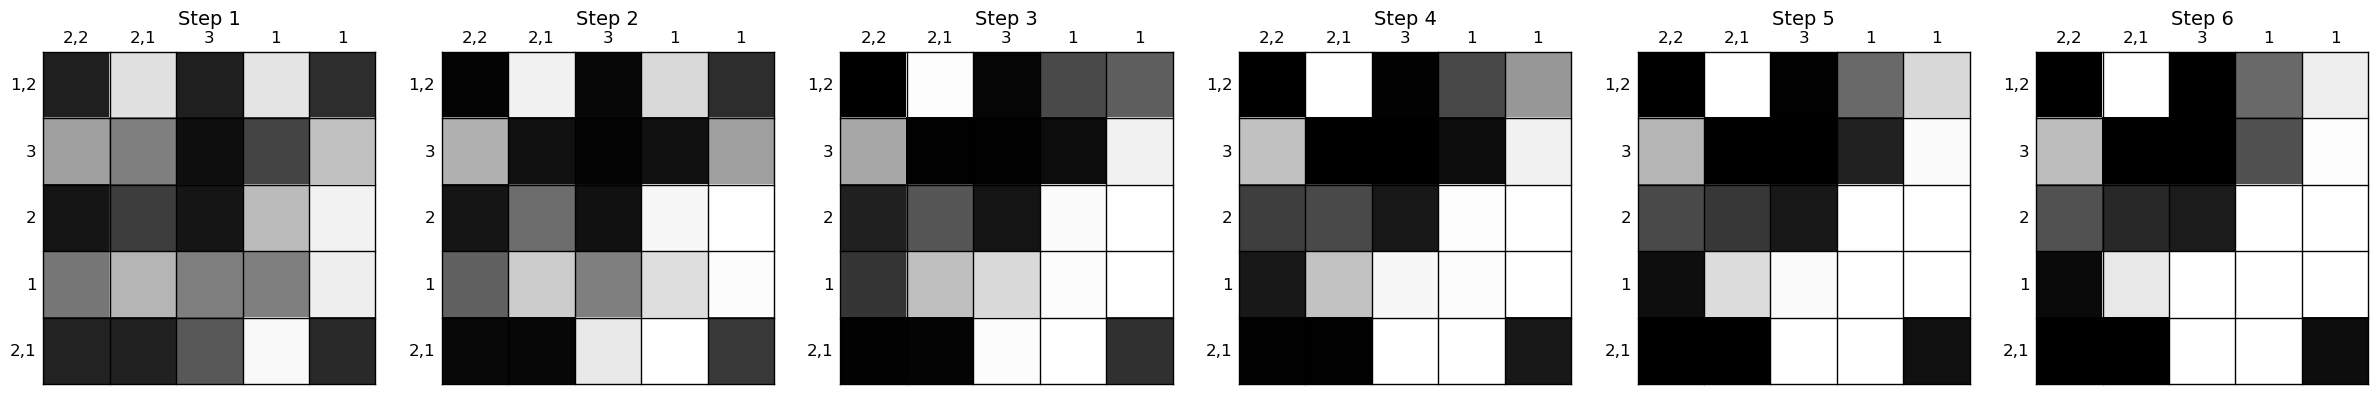

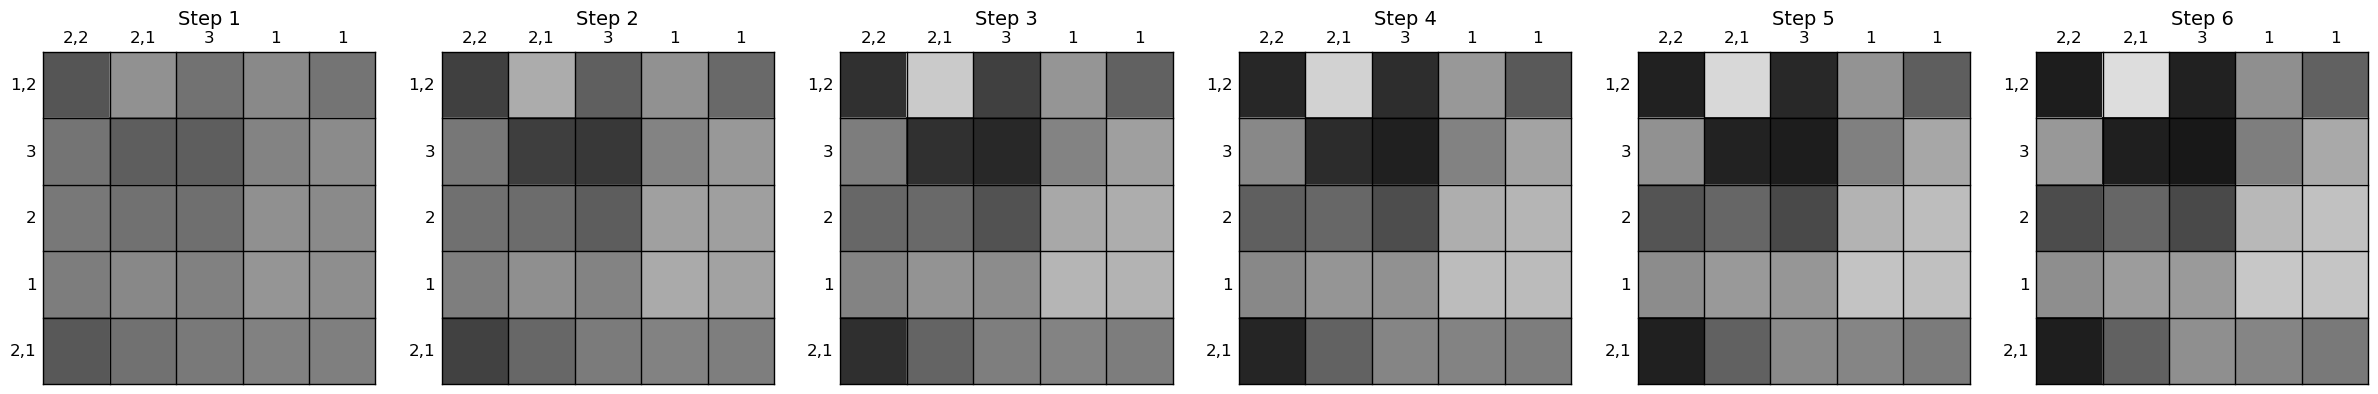

In [16]:
display_solution_trace(GDGlobalAdamSolver(step_size=1), sample_clues, display_steps=6, sampling_ratio=0.5, step_ratio=5)
display_solution_trace(GDGlobalSGDSolver(step_size=1), sample_clues, display_steps=6, sampling_ratio=0.5, step_ratio=20)
display_solution_trace(GDGaussSeidelAdamSolver(step_size=1), sample_clues, display_steps=6, sampling_ratio=0.5, step_ratio=5)
display_solution_trace(GDGaussSeidelSGDSolver(step_size=1), sample_clues, display_steps=6, sampling_ratio=0.5, step_ratio=20)
display_solution_trace(GDJacobiAdamSolver(step_size=1), sample_clues, display_steps=6, sampling_ratio=0.5, step_ratio=5)
display_solution_trace(GDJacobiSGDSolver(step_size=1), sample_clues, display_steps=6, sampling_ratio=0.5, step_ratio=20)

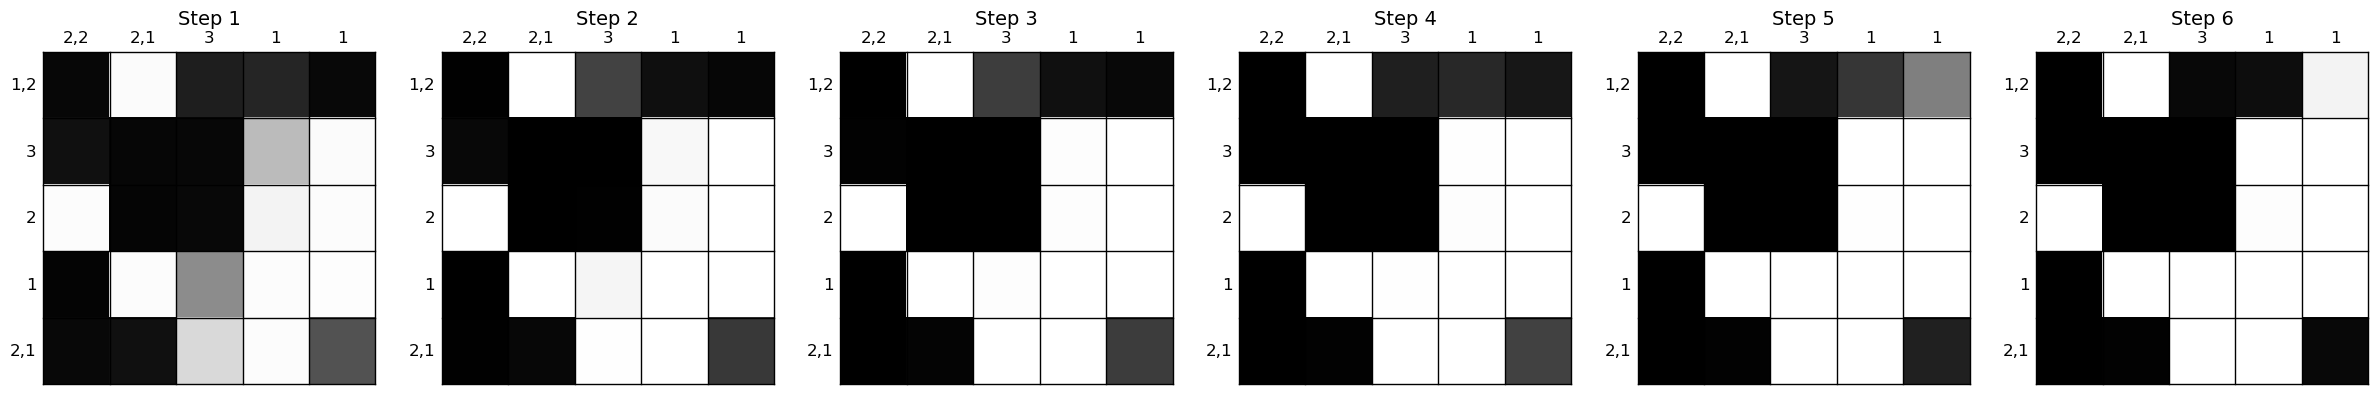

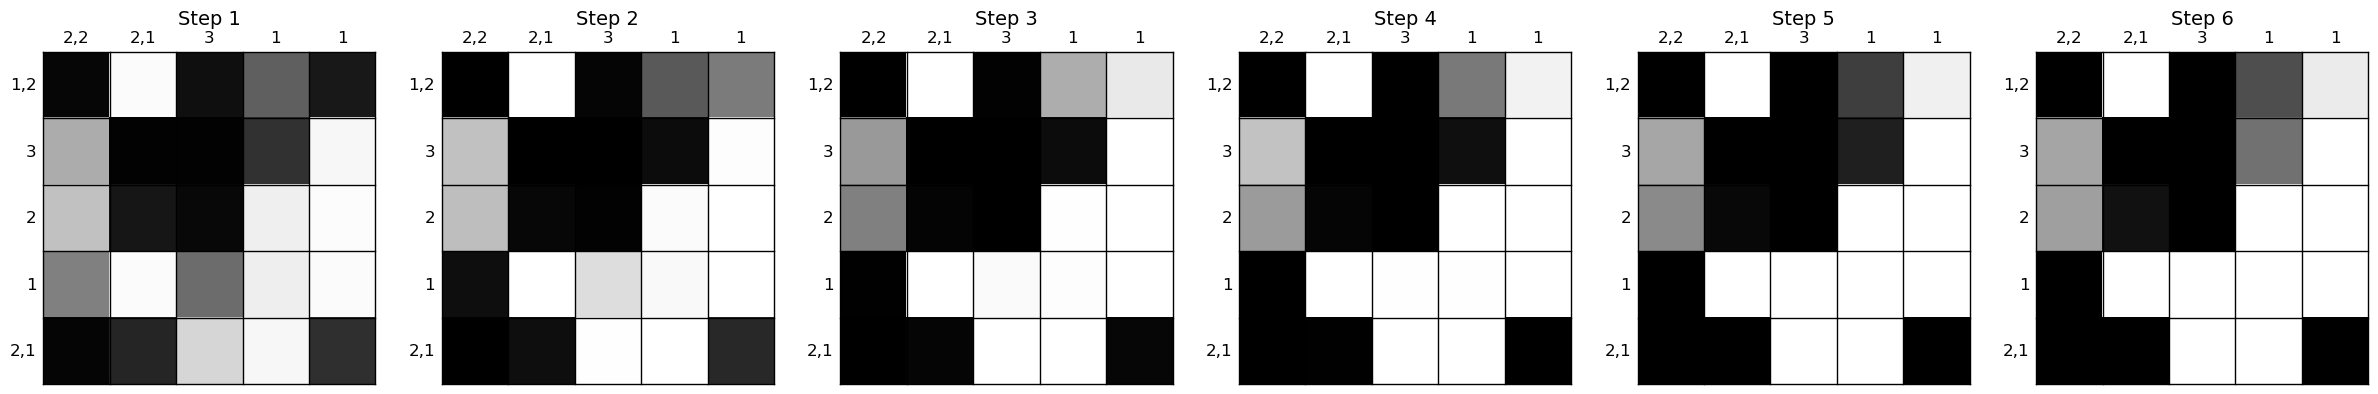

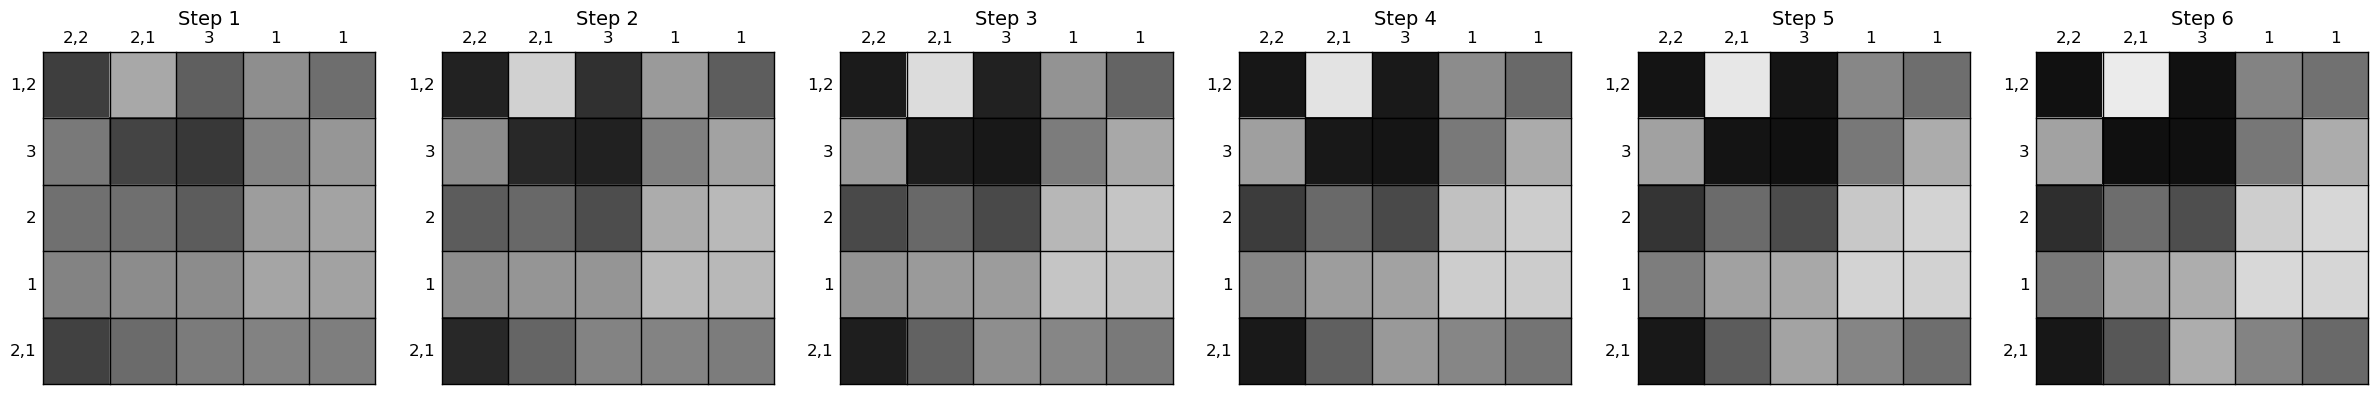

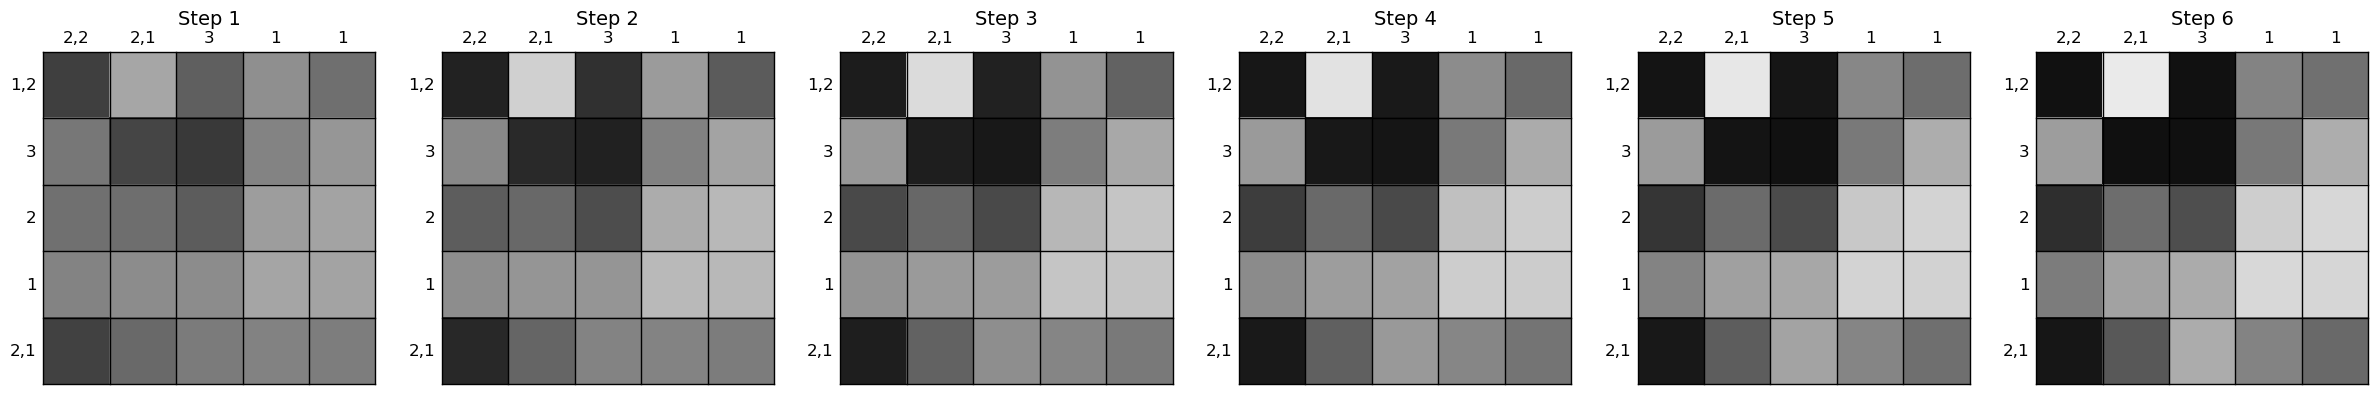

In [11]:
display_solution_trace(LocalMinViolationsSolver(step_size=1), sample_clues, display_steps=6, sampling_ratio=1.0, step_ratio=5)
display_solution_trace(GlobalMinViolationsSolver(step_size=1), sample_clues, display_steps=6, sampling_ratio=1.0, step_ratio=5)
display_solution_trace(LocalMinViolationsSolver(step_size=1, use_adam=False), sample_clues, display_steps=6, sampling_ratio=1.0, step_ratio=20)
display_solution_trace(GlobalMinViolationsSolver(step_size=1, use_adam=False), sample_clues, display_steps=6, sampling_ratio=1.0, step_ratio=20)


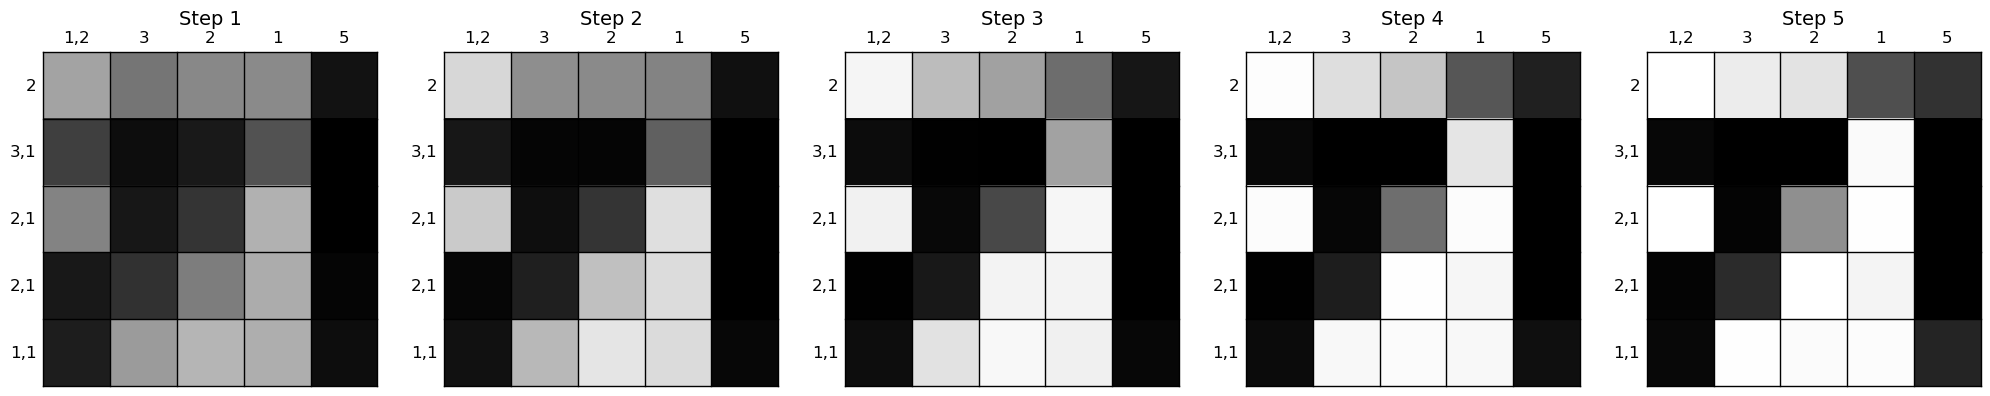

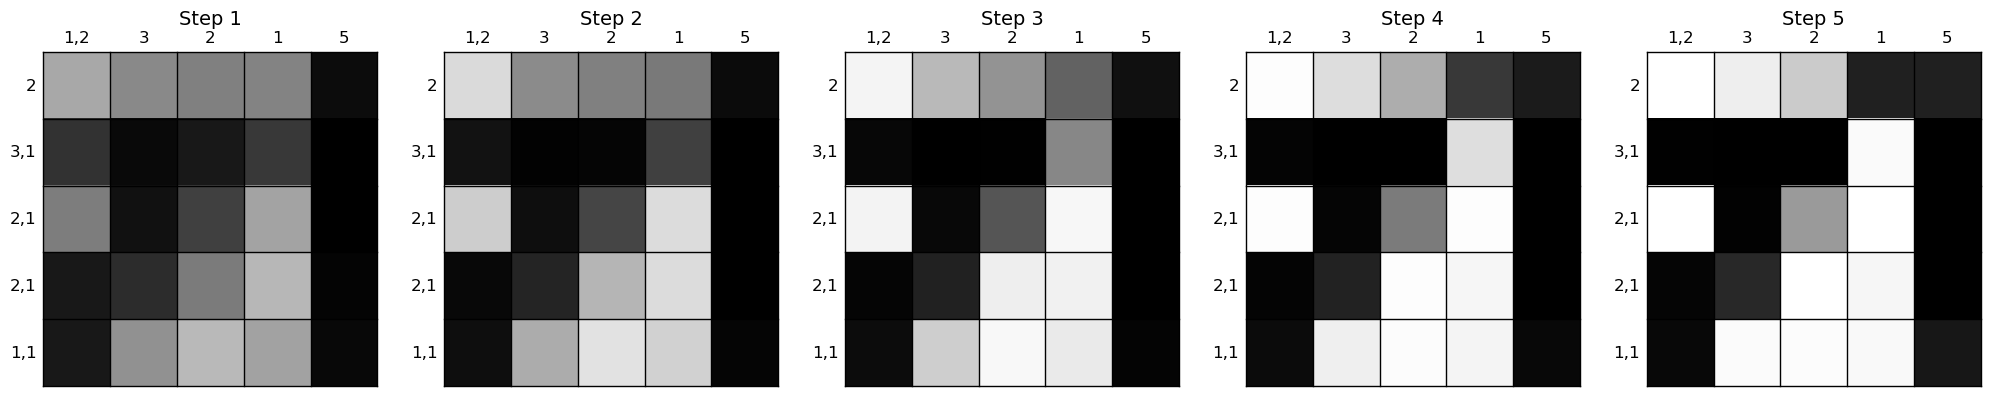

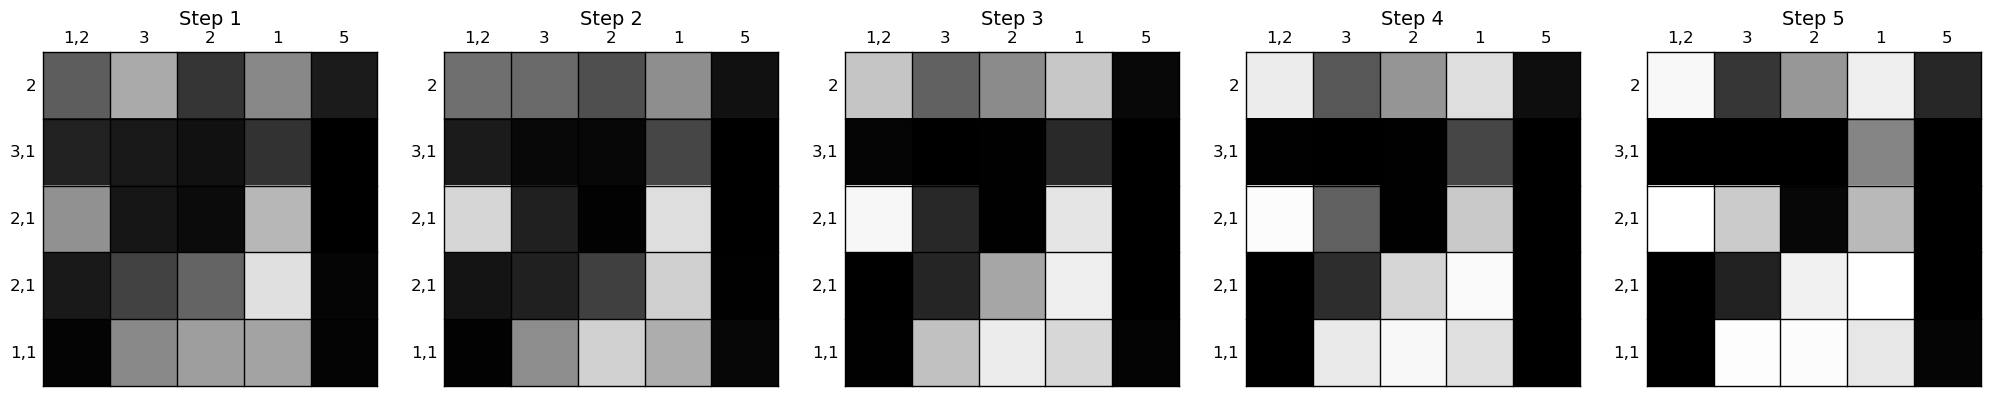

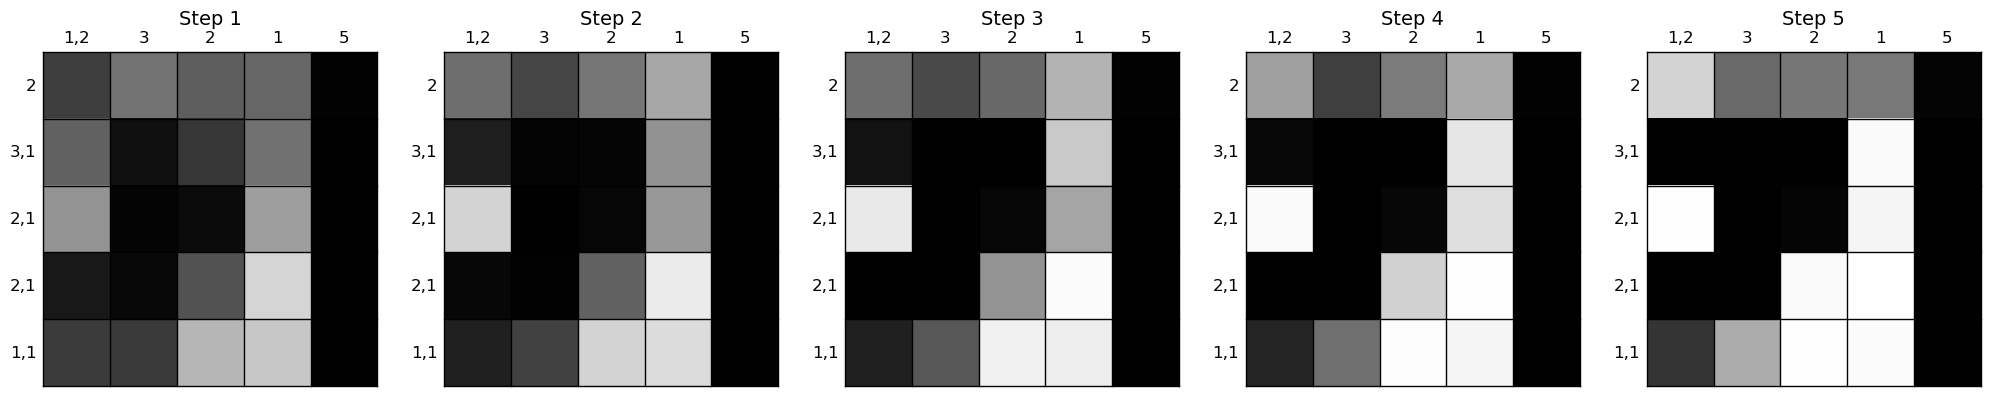

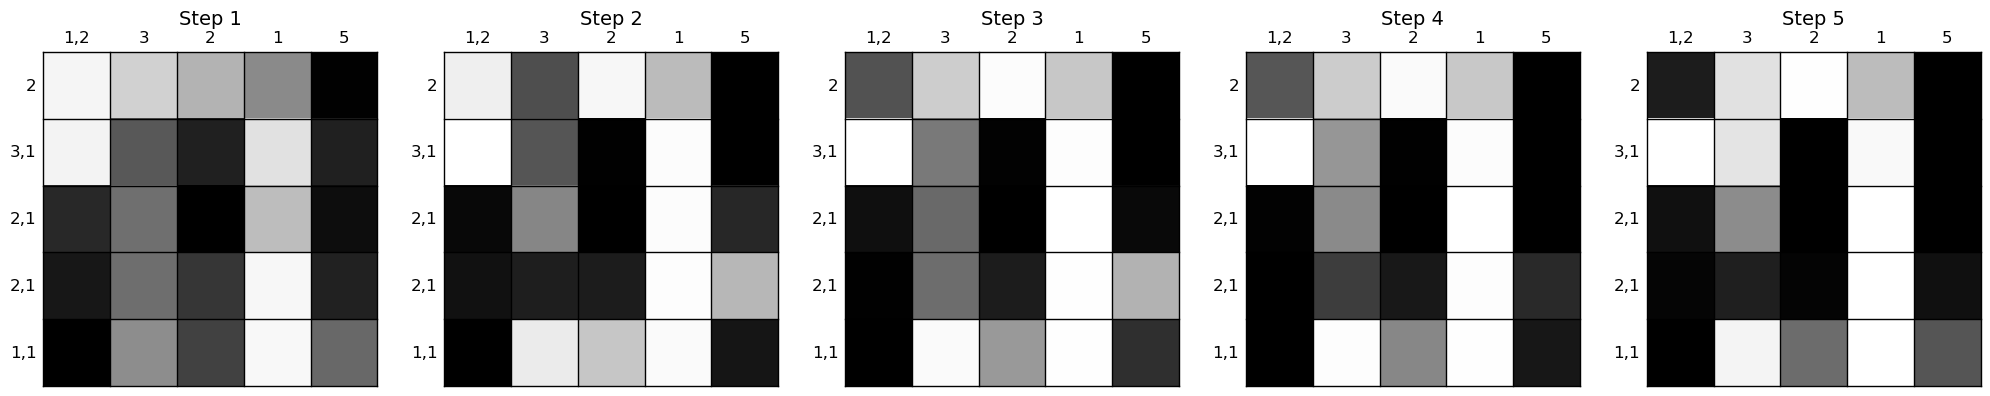

In [32]:
display_solution_trace(ModelSolver(), sample_clues, display_steps=5, sampling_ratio=1.0, step_ratio=2)
display_solution_trace(ModelSolver(), sample_clues, display_steps=5, sampling_ratio=0.9, step_ratio=2)
display_solution_trace(ModelSolver(), sample_clues, display_steps=5, sampling_ratio=0.5, step_ratio=2)
display_solution_trace(ModelSolver(), sample_clues, display_steps=5, sampling_ratio=0.5, step_ratio=2)
display_solution_trace(ModelSolver(), sample_clues, display_steps=5, sampling_ratio=0.2, step_ratio=2)